In [2]:
from my_fun.my_fun import fig_size, save_notebook_files
from analysis import *

In [3]:
ephys_id = '007_2024-06-24_17-47-22'
preprocessed = preprocess(ephys_id)
cluster_info = preprocessed.cluster_info
df_spikes = preprocessed.df_spikes
df_ttl = preprocessed.df_ttl
df_behavior = preprocessed.df_behavior
disengagement = find_disengaged(df_behavior, threshold=0.5, min_trial=200, win_len=20, plot=False)

Development mode: remote (minibaps, alexis, Linux)

Processor ID: 109, Stream Name: ProbeA-AP, Line: 1 (main sync line))
  First event sample number: 59449398
  Last event sample number: 230358711
  Total sync events: 6000
  Sample rate: 30000.0
Processor ID: 109, Stream Name: ProbeA-LFP, Line: 1 (aux sync line))
  First event sample number: 4954116
  Last event sample number: 19196559
  Total sync events: 4763
  Scale factor: 11.99999978936198
  Actual sample rate: 2500.0000438829215


Development mode: remote (minibaps, alexis, Linux)

All sounds sent by Bpod match those received by Arduino
There is(are) 1 more ephys trial(s) than behavior trial(s)
999 trials common to both data sources. Using it for later slicing
All sounds from behavior and ephys match


Min spike time: 0 min
Max spike time: 126 min


Total number of clusters: 830
Number of good clusters: 127 (15%)
Number of mua clusters: 559 (67%)
Number of noise clusters: 144 (17%)


The aquisition (press PLAY in Open Ephys) star

In [4]:
group = 'good'

# Slice out disengaged trials (based on accuracy)
df_behavior = df_behavior[df_behavior.Trial < disengagement]
df_ttl = df_ttl.iloc[:len(df_behavior)]

if group in ['good', 'mua']:
    clusters = cluster_info[cluster_info.group == group].cluster_id
elif group is None:
    clusters = cluster_info.cluster_id  # All

align = 'stim'
time_win = [-1, 3]
bin_size = 0.1

In [ ]:
figsize = fig_size(n_cols=0, ratio=None)  # A4 size in inches without margins
figsize = (figsize[1] - 1, figsize[0])
figsize

In [ ]:
# clusters = [93, 585, 218, 471]
# for cluster in clusters:
#     df_cluster = df_spikes[df_spikes.cluster == cluster]
#     cluster_report(df_cluster, cluster_info, df_ttl, df_behavior, align=align, time_win=time_win, bin_size=bin_size, save=False)

# Save all notebook's figures

In [ ]:
# # Whole notebook ouputs (no input or prompt, only Markdown and figures)
# # As HTML
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt
# # As PDF
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt
#
# Export all figures
save_notebook_files('notebook.ipynb')

In [5]:
event='StimStart'
# Convert string of lists back to lists
try:
    df_behavior["Port1In"] = df_behavior["Port1In"].apply(ast.literal_eval)
    df_behavior["Port2In"] = df_behavior["Port2In"].apply(ast.literal_eval)
except ValueError:
    # print('Port1In or Port2In are already lists')
    pass

licks_left = df_behavior.Port1In.copy()
licks_right = df_behavior.Port2In.copy()
for trial in range(len(df_behavior)):
    licks_left[trial] = [x - df_behavior[event].iloc[trial] for x in licks_left[trial]]  # Left
    licks_right[trial] = [x - df_behavior[event].iloc[trial] for x in licks_right[trial]]  # Right

In [7]:
indexes = get_trial_indexes(df_behavior, condition='stimulus')
left_trials = indexes[0]
right_trials = indexes[1]

In [9]:
bins, left_psth = compute_psth(licks_left, time_win=[-1, 3], bin_size=0.1)
bins, right_psth = compute_psth(licks_right, time_win=[-1, 3], bin_size=0.1)

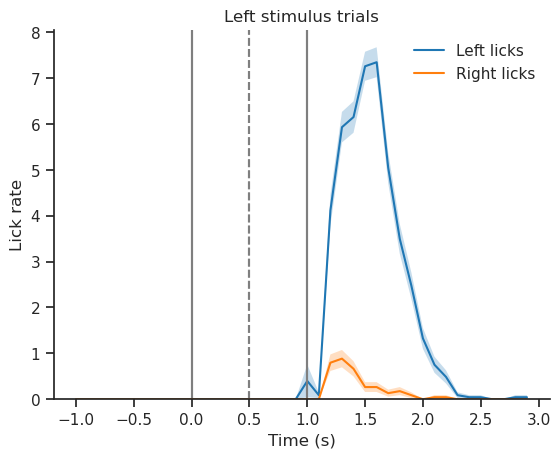

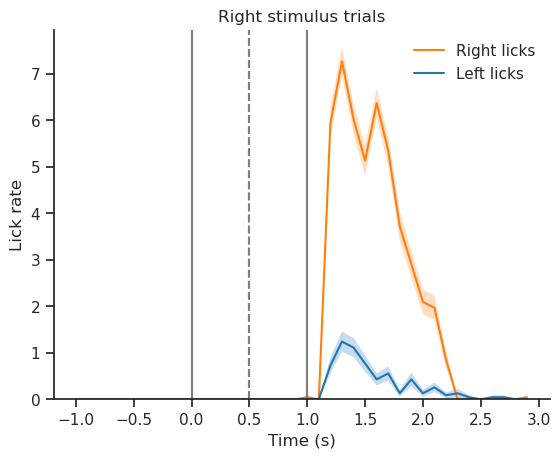

In [24]:
# Left trials
fig, ax = plt.subplots(1, 1)
plot_psth(bins, left_psth[left_trials], bin_size=0.1, color='tab:blue', label='Left licks', ax=ax)
plot_psth(bins, right_psth[left_trials], bin_size=0.1, color='tab:orange', label='Right licks', ax=ax)
plt.title('Left stimulus trials')
sns.despine()
plt.ylabel('Lick rate')
plt.legend(frameon=False)

# Right trials
fig, ax = plt.subplots(1, 1)
plot_psth(bins, right_psth[right_trials], bin_size=0.1, color='tab:orange', label='Right licks', ax=ax)
plot_psth(bins, left_psth[right_trials], bin_size=0.1, color='tab:blue', label='Left licks', ax=ax)
plt.title('Right stimulus trials')
sns.despine()
plt.ylabel('Lick rate')
plt.legend(frameon=False)